# U.S. Data & IT Job Market Analysis

## Project Overview
This project analyzes U.S. occupational employment and wage data to compare salary levels, job concentration, and geographic opportunities for data and IT-related roles. The goal is to identify which roles and states offer the strongest job market opportunities based on median salary and job concentration.

## Introduction
The job market is competitive and can vary drastically by state, especially for roles related to IT and data. As a Business-IT student with an interest in data analytics, I wanted to better understand the market I am preparing to enter. This project uses U.S. Bureau of Labor Statistics occupational wage data to answer three questions:

1. What does the overall salary landscape look like across all occupations?
2. How do data roles compare to broader IT roles in terms of salary and distribution?
3. Among the states I am interested in working in, which ones offer the best combination of salary and job concentration for data roles?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
pd.set_option('display.max_columns', 50)

## Data Source
The chosen dataset is sourced from the BLS Occupational Employment and Wage Statistics (OEWS) May 2024 release, a national survey which covers around 1.1 million establishments. The chosen state-level file provides wage estimates for approximately 830 occupations across all 50 states and DC.

In [3]:
# Read data file into dataframe
df = pd.read_csv("state_M2024_dl.csv")

## Data Cleaning and Preparation
Before analyzing the data, I cleaned and prepared the dataset by removing irrelevant rows and columns, removing invalid, duplicate, or missing data, converting columns to proper data types, and renaming selected column names for easier interpretation. I also created a new 'region' column for geographic analysis and finished by validating the cleaned dataset.

In [4]:
# Remove rows where data not taken from a state
df = df[df['AREA_TYPE'] == 2]

df = df[df['O_GROUP'] == 'detailed']

# Drop irrelevant columns
df = df.drop(columns=
             ["ANNUAL", "HOURLY", "NAICS_TITLE",'AREA', 'A_MEAN',
             'I_GROUP', 'OWN_CODE', 'O_GROUP', 'NAICS',
             'PCT_RPT', 'EMP_PRSE', 'H_MEAN', 'AREA_TYPE',
             'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'PCT_TOTAL',
             'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'OCC_CODE',
             'JOBS_1000', 'A_PCT10', 'A_PCT25', 'A_PCT75', 'A_PCT90']
            )



In [5]:
# Rename columns for easier interpretation
df = df.rename(columns= 
               {"OCC_TITLE": "job_title", "AREA_TITLE": "state", "A_MEDIAN": "median_salary",
                "LOC_QUOTIENT": "job_concentration", "TOT_EMP": "total_employment",
                "PRIM_STATE": "state_abbreviated"})

In [6]:
# Numerical data columns
cols = ['median_salary', 'total_employment', 'job_concentration']

# Replace invalid characters with null data
df[cols] = df[cols].apply(
    lambda x: x.astype(str).str.replace(r'[^\d.]', '', regex=True)
)

# Convert numerical data to numeric values instead of strings
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')


In [7]:
# Drop rows with null wage estimates
df = df.dropna(subset=['median_salary'], how='all')

In [8]:
# Remove any duplicate rows and reset index
df = df.loc[~df.duplicated()].reset_index(drop=True)

In [9]:
# Add region column for geographical analysis
def find_region(state):
    if state in {
        "Connecticut", "Maine", "Massachusetts", "New Hampshire", "Rhode Island", "Vermont", "New Jersey", "New York", "Pennsylvania"
        }:
        return "Northeast"
    elif state in {
        "Illinois", "Indiana", "Michigan", "Ohio", "Wisconsin", "Kansas", "Minnesota", "Missouri", "Nebraska", "North Dakota", "South Dakota"
    }:
        return "Midwest"
    elif state in {
        "Delaware", "District of Columbia", "Florida", "Georgia", "Maryland", "North Carolina", "South Carolina", "Virginia", "West Virginia", "Alabama",
          "Kentucky", "Mississippi", "Tennessee", "Arkansas", "Louisiana", "Oklahoma", "Texas"
    }:
        return "South"
    else:
        return "West"

df["region"]= df["state"].apply(find_region)

In [10]:
# View rows of data to validate proper columns and format
df.head()

,state,state_abbreviated,job_title,total_employment,job_concentration,median_salary,region
0,Alabama,AL,Chief Executives,830.0,0.29,164400.0,South
1,Alabama,AL,General and Operations Managers,32370.0,0.67,106330.0,South
2,Alabama,AL,Legislators,1120.0,3.10,26990.0,South
3,Alabama,AL,Advertising and Promotions Managers,50.0,0.16,133570.0,South
4,Alabama,AL,Marketing Managers,1660.0,0.32,112960.0,South


In [11]:
# Load cleaned data into a csv file
df.to_csv("cleaned_bls_oews_2024.csv", index=False)

## Exploratory Data Analysis

### Overall Salary Distribution

Before focusing on IT and data roles, I first examined the overall distribution of median annual salaries across all occupations in the dataset to better understand pay across the broader U.S. labor market.

Number of unique jobs: 824


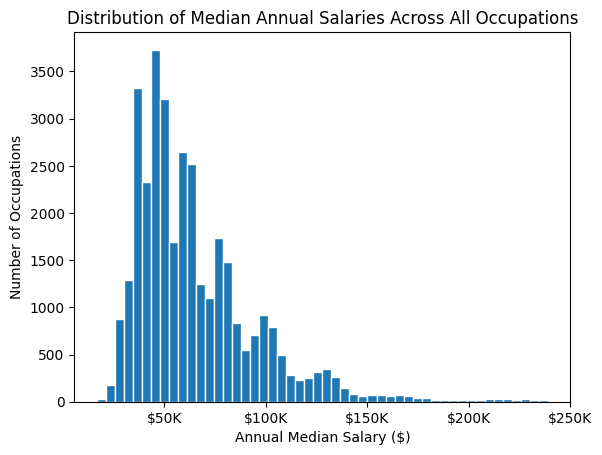

In [13]:
# Count unique jobs represented in dataset
print(f"Number of unique jobs: {df['job_title'].nunique()}")

# Create histogram showing distribution of median salaries of all occupations
df['median_salary'].plot(kind="hist", bins=50, edgecolor='white')

plt.title("Distribution of Median Annual Salaries Across All Occupations")
plt.xlabel("Annual Median Salary ($)")
plt.ylabel("Number of Occupations")

# Formats x-axis values as dollar amounts
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.savefig("images/overall_salary_distribution.png", bbox_inches="tight", dpi=300)
plt.show()


Distribution of median salaries is right-skewed, with most occupations falling between a $40K-$80K median salary. There is a tail extending towards $150K, representing specialized roles in which there are fewer available jobs.

### Regional Salary Comparison

To understand broad salary differences across the U.S., I grouped jobs by region and calculated the median salary for each region, providing an overview of how salary level varies by location before focusing on IT/Data roles.

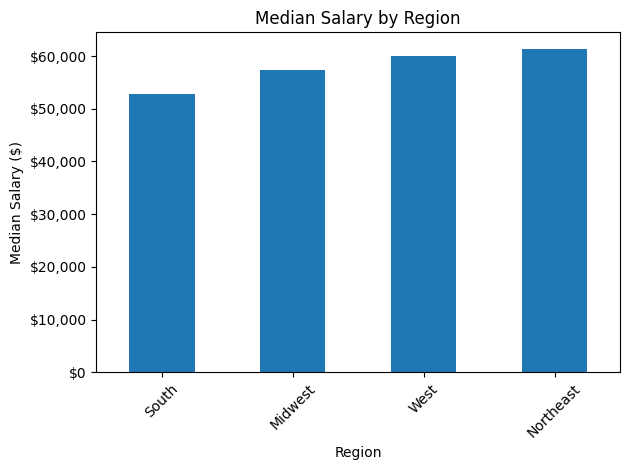

In [15]:
# Groups data by region and calculates regional median salary
by_region = (
    df.groupby("region")['median_salary']
    .median()
    .sort_values()
    .reset_index()
)

# Creates bar plot to compare median salaries by region
by_region.set_index("region").plot(kind="bar", legend=False)

plt.title("Median Salary by Region")
plt.xlabel("Region")
plt.ylabel("Median Salary ($)")
plt.xticks(rotation = 45)

# Formats y-axis values as dollar amounts
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()

plt.savefig("images/regional_salary_comparison.png", bbox_inches="tight", dpi=300)
plt.show()

The Northeast and West lead all regions in median salary, which likely reflects a higher concentration of high-skill roles in those areas, but potentially also higher costs of living.

### IT and Data Role Comparison
To see where data roles fit within the broader IT job market, I selected 12 IT jobs from the dataset and classified 5 of them as data-specific roles. The boxplot below shows how median salaries vary for each role across all states, making it easier to compare salary levels and variation by occupation.

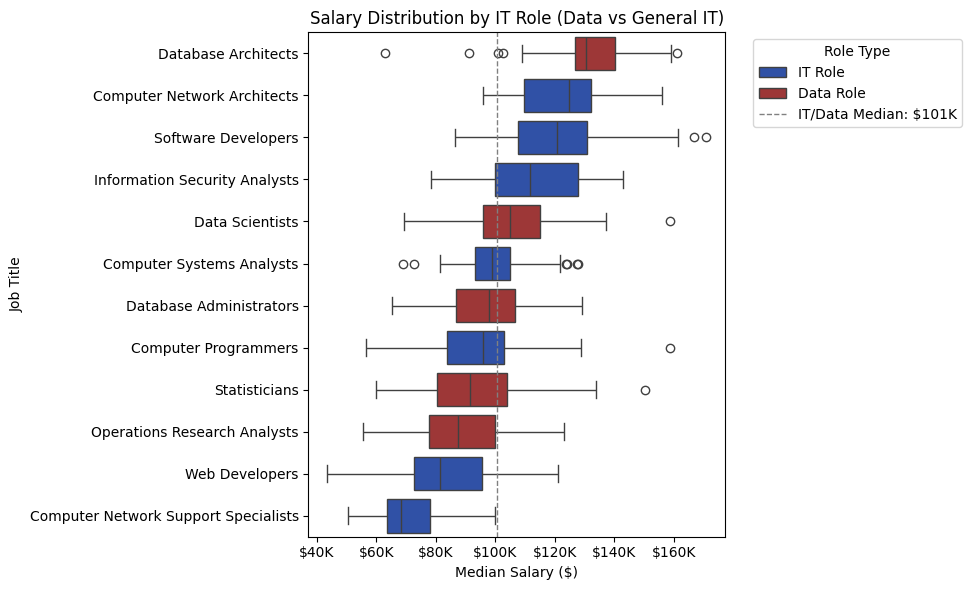

In [14]:
# Selected IT roles for analysis
it_roles_list = ['Database Administrators', 'Database Architects', 'Data Scientists', 'Computer Systems Analysts',
                 'Software Developers', 'Computer Programmers', 'Computer Network Architects', 'Web Developers',
                 'Computer Network Support Specialists', 'Information Security Analysts', 'Statisticians', 'Operations Research Analysts']

# Selected subset of data-specific IT roles
data_roles_list = [ 'Database Administrators', 'Database Architects', 'Data Scientists', 'Statisticians', 'Operations Research Analysts']

# Creates dataframe of selected IT roles
it_roles = (
    df.query("job_title in @it_roles_list").copy()
)

# Classified IT roles as data-specific or general IT
it_roles['role_type'] = it_roles['job_title'].apply(
    lambda x: 'Data Role' if x in data_roles_list else 'IT Role'
)

# Defines coloring between data and it roles in boxplot
palette = {
    'Data Role': "#AE2626",
    'IT Role': '#1C49BA'
}

# Define ordering for jobs in boxplot to be median salary in descending order
order = (
    it_roles.groupby("job_title")["median_salary"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

# Create boxplot to compare salary distributions across selected IT and data roles
ax = sns.boxplot(
    data = it_roles, 
    x="median_salary", 
    y="job_title",
    hue='role_type',
    legend=True,
    palette=palette,
    order=order
)

# Creates reference line for median salary across the selected IT and data roles
overall_median = it_roles['median_salary'].median()
ax.axvline(x=overall_median, color='gray', linestyle='--', linewidth=1, label=f'IT/Data Median: ${overall_median/1000:.0f}K')

ax.legend(title="Role Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("Median Salary ($)")
ax.set_ylabel("Job Title")
ax.set_title("Salary Distribution by IT Role (Data vs General IT)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig("images/it_data_salary_boxplot.png", bbox_inches="tight", dpi=300)
plt.show()

The boxplot shows that salary levels vary widely across IT and data roles. The dashed line represents the median salary among the selected roles, and sits at approximately $101K. Database Architects are the highest-paying role, which makes sense because it is a more specialized and senior role. Most data roles fall near or above the median salary with the exception of Operations Research Analysts. The wider salary ranges and outliers for roles such as Software Developers, Data Scientists, and Computer Programmers suggest that location has a strong impact on earning potential. Overall, the chart indicates that data roles offer competitive salaries within the broader IT job market.

### Geographic Analysis for Data Roles
While salary is important, it is also necessary to consider how many jobs are available. Job concentration measures how many data roles are represented in the given state compared with the national average. A value of 1.0 means the state is equal to the national average, values below 1.0 indicate lower-than-average concentration, and values above 1.0 indicate higher-than-average concentration. I calculated a weighted average location quotient for each state, where roles with higher employment totals carried more influence than smaller ones.  

The scatter plot compares median salary and job concentration for data roles across states. Highlighted are five states that I am interested in working in.

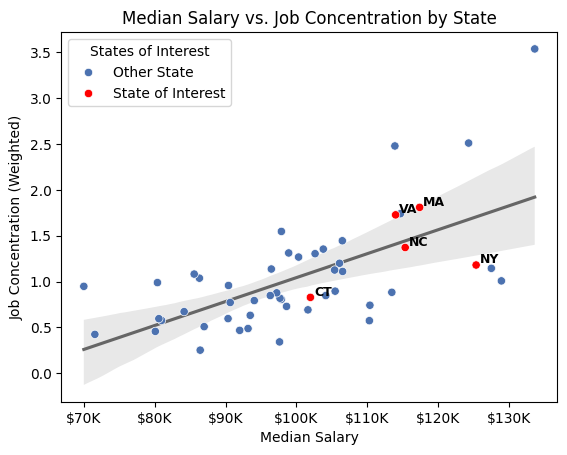

In [16]:
# Filter to data roles
data_roles = it_roles.query("role_type == 'Data Role'")

# Calculate employment-weighted job concentration by state
weighted_jc = (
    data_roles.groupby('state_abbreviated')
    .apply(lambda x: (x['job_concentration'] * x['total_employment']).sum() / x['total_employment'].sum())
    .reset_index()
    .rename(columns={0: 'weighted_jc'})
    .sort_values('weighted_jc', ascending=False)
    )

# Calculate median salary for data roles by state
median_salary = (
    data_roles.groupby('state_abbreviated')['median_salary']
    .median()
    .reset_index()
    .sort_values('median_salary', ascending=False)
)

# Combine calculated salary and weighted job concentration data into one dataset based on state
state_jc_salary = median_salary.merge(right=weighted_jc, on='state_abbreviated', how='inner')

# Defines states I am interested in working in
states_of_interest = ['NC', 'NY', 'VA', 'CT', 'MA']

# Classify states as of interest or other
state_jc_salary['of_interest'] = state_jc_salary['state_abbreviated'].apply(
    lambda x: 'State of Interest' if x in states_of_interest else 'Other State'
)

# Defines coloring for states of interest and other states
palette = {
    'State of Interest': 'red',
    'Other State': '#4C72B0'
}

# Create trendline to show the overall relationship between salary and job concentration
sns.regplot(
    data=state_jc_salary,
    x="median_salary",
    y="weighted_jc",
    color='#666666',
    scatter=False
)

# Create scatterplot to compare median salary and job concentration among states for data roles
sns.scatterplot(
    data=state_jc_salary,
    x="median_salary",
    y="weighted_jc",
    hue='of_interest',
    palette=palette,
    zorder=2
)

ax = plt.gca()

# Label states of interest with their abbreviated names
for _, row in state_jc_salary.iterrows():
    if row['of_interest'] == 'State of Interest':
        ax.text(
            row['median_salary'] + 500,
            row['weighted_jc'] + 0.02,
            row['state_abbreviated'],
            fontsize=9,
            weight='bold',
            color='black',
            zorder=10
        )

ax.set_title("Median Salary vs. Job Concentration by State")
ax.set_xlabel("Median Salary")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylabel("Job Concentration (Weighted)")
ax.legend(title="States of Interest", loc='best')

plt.savefig("images/salary_jc_scatterplot.png", bbox_inches="tight", dpi=300)
plt.show()



The scatterplot shows a positive correlation between salary and job concentration, meaning that states with higher salaries for data roles tend to have a higher concentration of data roles. Of the states I'm considering, North Carolina stands out as offering high job concentration and salary with a likely lower cost of living. Massachusetts and Virginia also offer high concentration and salaries, but likely have higher costs of living. New York has the highest median pay out of highlighted states but a lower concentration than expected, suggesting a more selective market. Connecticut has below average job concentration and salary for data roles, which suggests a less developed market for data roles.

## Conclusions
This analysis examined salary distributions and job markets for data and IT roles across the United States. Three key findings emerge:

**1. Data roles are among the highest paying within IT**  
Data Scientists and Database Architects rank at the top of the selected IT salary distribution, consistently exceeding the overall IT median of $101K. However, salary can vary significantly by state.

**2. The data job market is geographically concentrated**  
Data roles are not evenly distributed across the country, with some states having much higher concentrations than others, suggesting that many states have a less developed market for data roles with fewer opportunities for entry-level candidates.

**3. North Carolina is a strong market for entry-level data professionals**  
Among the highlighted states, North Carolina offers the strongest combination of above-average job concentration and competitive salary without the higher costs of living in states like Massachusetts or New York.

**Limitations**  
The dataset does not take into account regional differences in pay/opportunity within states. For example, a rural area in North Carolina is an entirely different market than a city like Raleigh or Charlotte. Additionally, cost of living differences are not included in the dataset. Incorporating a cost of living index by state would allow for a more meaningful salary comparison across states. Finally the dataset does not include values for salaries above $239,200, and some wage estimates are not available, which could introduce gaps in coverage.